# Análise implementação multiprocessamento (MPI)

**Universidade Estadual de Santa Cruz - UESC**

**Discente:** Everaldina Guimarães Barbosa

**Docente:** Prof. Dr. Esbel Tomas Valero Orellana

**Disciplina:** Processamento Paralelo

## 1. Introdução

Este relatório teve como objetivo analisar o desempenho computacional de um programa desenvolvido em C++, estruturado em duas abordagens: uma sequencial e outra utilizando arquitetura de multiprocessos (MPI). Foram comparados os tempos de execução de uma mesma tarefa nas duas implementações, com o intuito de avaliar a eficiência do processamento paralelo. Além disso, também foi realizada a comparação entre a implementação com MPI e a implementação com OpenMP, que utiliza multithreading.

O sistema consistiu na verificação da similaridade entre pares de tomografias computadorizadas (A e B) tridimensionais, com dimensões representadas por (X, Y, Z). A metodologia do algoritmo baseou-se em extrair o corte central do eixo Z da tomografia A e compará-lo com todos os cortes ao longo do eixo Z da tomografia B. Para quantificar essa correspondência, adotou-se a métrica do Índice de Similaridade Estrutural (SSIM). Ao final da varredura, a aplicação retornava o valor máximo de similaridade detectado, juntamente com o índice numérico do corte da tomografia B correspondente.

Todo o código-fonte, englobando a implementação em C++, os *scripts* de teste, os *notebooks* e os resultados obtidos, encontra-se publicamente disponível no repositório do projeto: [processamento-paralelo](https://github.com/everaldina/processamento-paralelo).

## 2. Metodologia

### 2.1 Conjunto de dados

Os experimentos foram conduzidos utilizando o conjunto de dados *OrcaScore*, que dispõe de 72 pares de tomografias computadorizadas cardíacas. Cada par é constituído por uma imagem capturada com injeção de contraste e outra sem contraste, ambas possuindo dimensões de (512, 512, Z). A profundidade Z varia entre 167 e 640 cortes para as imagens com contraste, e entre 36 e 64 cortes para as imagens sem contraste.

A base é originalmente dividida em três subconjuntos: treino (32 pares), teste (32 pares) e validação (8 pares), cujas aquisições vinham de quatro tomógrafos distintos, designados como V1, V2, V3 e V4. Visando otimizar o tempo de processamento e viabilizar a execução de todos os cenários de teste, os exames originários do equipamento V2 foram restritos apenas ao conjunto de validação, reduzindo a amostra total analisada para 56 pares. Essa restrição foi adotada porque as tomografias com contraste do equipamento V2 apresentavam um volume de cortes superior (mínimo de 480 cortes) em comparação aos demais (máximo de 380 cortes), o que elevaria o custo computacional a níveis que inviabilizariam os prazos do projeto.

### 2.2 Indice de Similaridade Estrutural (SSIM)

A lógica de cálculo do SSIM foi fundamentada na implementação da biblioteca *scikit-image*, nativa da linguagem Python, especificamente no módulo [structural_similarity](https://github.com/scikit-image/scikit-image/blob/main/src/_skimage2/metrics/_structural_similarity.py). O código Python de referência foi preservado no momento da implementação em C++ no arquivo [function_base.py](ref_codes/function_base.py), presente no repositório do projeto.

Foi realizada uma tradução direta do código em Python para C++, visando assegurar a mesma fidelidade matemática no programa principal. Essa implementação pode ser encontrada no arquivo [ssim_impl.hpp](src/metrics/ssim_impl.hpp).

### 2.3 Resumo de implementação

Para a implementação com MPI, o número de processos não é passado como parâmetro do programa: ele é definido no momento da execução, por meio do comando mpiexec -n <num_processos>. Também há o tamanho do kernel, que é definido como parâmetro de linha de comando (-k).

A estrutura do programa manteve o mesmo padrão de iteração sobre os pares de imagens e a inversão da ordem de comparação. Porém, nessa versão todos os processos executam a mesma sequência de instruções do laço principal: o volume de dados de B é dividido entre os processos, e cada um calcula, localmente em sua fatia de dados, o valor máximo de SSIM e o índice do corte correspondente. Ao final, os resultados parciais são enviados ao processo de rank 0, que realiza a redução dos resultados e escreve o arquivo de log.

Diferentemente da versão OpenMP, na versão MPI cada processo possui seu próprio espaço de memória isolado. Por esse motivo, a leitura em disco foi restrita exclusivamente ao processo de rank 0, evitando acessos concorrentes ao mesmo arquivo e leituras redundantes. Em seguida, o processo 0 distribuiu aos demais processos apenas as informações estritamente necessárias para o cálculo, por meio de operações de comunicação (MPI_Bcast e MPI_Scatterv).

Foram transmitidas por broadcast: 
 - 1. Um sinalizador de sucesso da leitura, permitindo que todos os processos abortem com segurança caso a leitura falhe;
 - 2. Os metadados da imagem (dimensões e quantidade de cortes de B);
 - 3. O corte central da imagem A, utilizado por todos os processos como referência de comparação.
 
Já o volume de cortes da imagem B não foi replicado entre os processos: cada processo recebeu apenas o subconjunto de cortes que lhe cabia processar, por meio de um MPI_Scatterv. A divisão do número de cortes pelo número de processos nem sempre é exata; portanto, o resto da divisão foi redistribuído entre os primeiros processos, garantindo que a carga entre eles ficasse o mais balanceada possível.

Uma redução por máximo com localização (MPI_MAXLOC) foi aplicada sobre uma estrutura contendo o par {SSIM, índice do corte}, permitindo obter em uma única operação o maior valor de SSIM entre todos os processos e o índice do corte correspondente.

Todas as reduções direcionavam o resultado consolidado ao processo de rank 0, único responsável por calcular as métricas finais e escrever o log de saída.

Todo o processamento gerava saídas formatadas em logs de texto, escritas exclusivamente pelo processo de rank 0, onde foram registrados os IDs das imagens, o kernel, o número de processos e os tempos obtidos. Assim como nas demais versões, o tempo de escrita nos arquivos foi isolado propositalmente para não impactar nem poluir as métricas de comparação de desempenho do sistema.

### 2.4 Testes realizados

A execução da versão sequencial englobou os 72 pares de imagens originais, testados sob os *kernels* 3, 5, 7 e 9. Cada combinação de imagem e *kernel* foi executada 10 vezes com a alternância das imagens A e B, resultando em 5.760 testes globais. Foi feito um teste de corretude, comparando diretamente as saídas computadas em C++ com uma réplica implementada em Python, garantindo a fidelidade do algoritmo. Esses testes podem ser encontrados no arquivo [omp_parallel.ipynb](notebooks/omp_parallel.ipynb), no repositório do projeto.

Para a abordagem MPI, limitou-se o escopo aos *kernels* 5, 7 e 9 e a 5 repetições por par, com a filtragem de dados descrita na seção 2.1. Para cada *kernel*, foram empregados diferentes números de processos: os testes foram realizados com 2, 4 e 8 processos simultâneos, totalizando 5.040 testes.

Após a realização dos testes com MPI, todos os resultados voltaram a ser comparados com os resultados da versão sequencial, garantindo a integridade do processamento paralelo.

Também foi realizada a comparação entre os tempos de execução da versão MPI e da versão OpenMP, com o intuito de avaliar a eficiência do processamento paralelo em ambas as abordagens.

### 2.5 Hardware e software utilizados

A execução de todos os testes ocorreu em uma máquina equipada com processador Intel Core i5-1135G7 @ 2.40GHz (4 núcleos físicos, 8 núcleos lógicos) e 8 GB de memória RAM, executando o sistema operacional Windows 11. O compilador adotado foi o `g++` (via MinGW), acionado com as diretivas `-lmsmpi` para suporte ao multiprocessamento e `-O3` para o nível máximo de otimização de código.

## 3. Resultados

- Preparação do ambiente

In [1]:
import os
from log_utils import read_log, parse_log
from corretude import teste_corretude
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
NUCLEOS_FISICOS = 4
NUCLEOS_LOGICOS = 8
OUTPUT_DIR = os.path.join('..', 'output')

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### 3.1 Teste de corretude

Para validar a corretude da implementação MPI, foram comparados os resultados obtidos com a versão sequencial, os quais foram anteriormente validados com a implementação em Python.

A comparação foi realizada utilizando o *script* `notebooks/corretude.py`, que recebe dois dataframes contendo os resultados de cada versão, e verifica se:

1. Há apenas um valor máximo de SSIM para cada par de imagens, garantindo que o algoritmo não tenha retornado múltiplos valores máximos.
2. Há apenas um índice de corte correspondente ao valor máximo de SSIM, assegurando que o algoritmo tenha identificado corretamente o corte da imagem B que apresenta a maior similaridade com a imagem A.
3. Os valores máximos de SSIM são iguais ou muito próximos entre as duas versões, considerando uma tolerância padrão de 1e-25.

In [4]:
# Lendo logs sequenciais
file_path = os.path.join('..', 'output', 'sequencial.txt')
if os.path.exists(file_path):
    with open(file_path, 'r') as f:
        log_content = f.read()
    sequencial = parse_log(log_content)
    df_seq = pd.DataFrame(sequencial)
else:
    print(f"Arquivo {file_path} não encontrado.")

In [5]:
df_seq['threads'] = None
df_seq['type'] = 'sequencial'

In [6]:
data_frames = []
threads = [2, 4, 8]
kernels = [5, 7, 9]

In [7]:
### leitura mpi ###
for thread in threads:
    for kernel in kernels:
        filename = f"mpi_t{thread}_k{kernel}.txt"
        filepath = os.path.join(OUTPUT_DIR, filename)
        if os.path.exists(filepath):
            log_content = read_log(filepath)
            df = parse_log(log_content)
            data_frames.append(df)
            df['threads'] = thread
            df['type'] = 'mpi'
            data_frames.append(df)
        else:
            print(f"Arquivo {filename} não encontrado.")

df_mpi = pd.concat(data_frames, ignore_index=True)

In [8]:
result = teste_corretude(df_ref = df_seq[df_seq['windows_size'] == '5'],
                         df_comp = df_mpi[df_mpi['windows_size'] == '5'], 
                         lista_ids = df_mpi['id'].unique(), 
                         nome_ref = 'Sequencial', 
                         nome_comp = 'MPI')
print(f"Total de comparações: {result['num_comp']}")
print(f"Diferenças encontradas nos melhores cortes: {result['num_index_diff']}")
print(f"Diferenças encontradas nos valores de SSIM: {result['num_ssim_diff']}")

ID TRV1P1 | Cortes 280
  - Resultados consistentes
ID TRV1P1 | Cortes 64
  - Resultados consistentes
ID TRV1P2 | Cortes 56
  - Resultados consistentes
ID TRV1P2 | Cortes 182
  - Resultados consistentes
ID VAV4P1 | Cortes 48
  - Resultados consistentes
ID VAV4P1 | Cortes 348
  - Resultados consistentes
ID VAV4P2 | Cortes 48
  - Resultados consistentes
ID VAV4P2 | Cortes 332
  - Resultados consistentes
Total de comparações: 112
Diferenças encontradas nos melhores cortes: 0
Diferenças encontradas nos valores de SSIM: 0


In [9]:
result = teste_corretude(df_ref = df_seq[df_seq['windows_size'] == '7'],
                         df_comp = df_mpi[df_mpi['windows_size'] == '7'], 
                         lista_ids = df_mpi['id'].unique(), 
                         nome_ref = 'Sequencial', 
                         nome_comp = 'MPI')
print(f"Total de comparações: {result['num_comp']}")
print(f"Diferenças encontradas nos melhores cortes: {result['num_index_diff']}")
print(f"Diferenças encontradas nos valores de SSIM: {result['num_ssim_diff']}")

ID TRV1P1 | Cortes 280
  - Resultados consistentes
ID TRV1P1 | Cortes 64
  - Resultados consistentes
ID TRV1P2 | Cortes 56
  - Resultados consistentes
ID TRV1P2 | Cortes 182
  - Resultados consistentes
ID VAV4P1 | Cortes 48
  - Resultados consistentes
ID VAV4P1 | Cortes 348
  - Resultados consistentes
ID VAV4P2 | Cortes 48
  - Resultados consistentes
ID VAV4P2 | Cortes 332
  - Resultados consistentes
Total de comparações: 112
Diferenças encontradas nos melhores cortes: 0
Diferenças encontradas nos valores de SSIM: 0


In [10]:
result = teste_corretude(df_ref = df_seq[df_seq['windows_size'] == '9'],
                         df_comp = df_mpi[df_mpi['windows_size'] == '9'], 
                         lista_ids = df_mpi['id'].unique(), 
                         nome_ref = 'Sequencial', 
                         nome_comp = 'MPI')
print(f"Total de comparações: {result['num_comp']}")
print(f"Diferenças encontradas nos melhores cortes: {result['num_index_diff']}")
print(f"Diferenças encontradas nos valores de SSIM: {result['num_ssim_diff']}")

ID TRV1P1 | Cortes 280
  - Resultados consistentes
ID TRV1P1 | Cortes 64
  - Resultados consistentes
ID TRV1P2 | Cortes 56
  - Resultados consistentes
ID TRV1P2 | Cortes 182
  - Resultados consistentes
ID VAV4P1 | Cortes 48
  - Resultados consistentes
ID VAV4P1 | Cortes 348
  - Resultados consistentes
ID VAV4P2 | Cortes 48
  - Resultados consistentes
ID VAV4P2 | Cortes 332
  - Resultados consistentes
Total de comparações: 112
Diferenças encontradas nos melhores cortes: 0
Diferenças encontradas nos valores de SSIM: 0


De todos os testes realizados, nenhum apresentou divergência entre os resultados da versão sequencial e da versão MPI, confirmando a corretude do algoritmo paralelo.

## 3.2 Comparação de resultados entre execução serial e multiprocessos

In [11]:
df_final = pd.concat([df_seq, df_mpi], ignore_index=True)
df_final['threads'] = df_final['threads'].astype(float)

In [12]:
colunas_agrupamento = ['id', 'cortes', 'threads', 'type', 'windows_size']
colunas_tempo = ['tempo_leitura', 'tempo_medio_slice', 'tempo_busca', 'tempo_total']

df_medio = df_final.groupby(colunas_agrupamento, dropna=False)[colunas_tempo].mean().reset_index()

Os resultados obtidos com a versão MPI foram consolidados em um *dataframe* e mesclados com os resultados da versão sequencial, permitindo a análise comparativa entre as duas abordagens. Além disso, foi feita a adição de métricas de desempenho, como o *speedup* e a eficiência do processamento paralelo, calculadas com base nos tempos médios de execução.

Como a máquina possui apenas 4 núcleos físicos, a execução com 8 processos não representa uma execução totalmente paralela. Por esse motivo, a métrica de eficiência (E = Speedup / num_processos) foi calculada considerando como número de processos o número de núcleos físicos, ou seja, 4.

In [13]:
# separacao de dados sequenciais
df_seq = df_medio[df_medio['type'] == 'sequencial'].copy()
df_seq = df_seq[['id', 'tempo_total', 'windows_size', 'cortes']].rename(columns={'tempo_total': 'tempo_total_seq'})

# separacao de dados paralelos
df_par = df_medio[df_medio['type'] != 'sequencial'].copy()

# juncao dos dados sequenciais e paralelos para analise de speedup e eficiencia
df_analise = df_par.merge(df_seq, on=['id', 'windows_size', 'cortes'], how='inner')

# calculo de speedup e eficiencia
df_analise['speedup_total'] = df_analise['tempo_total_seq'] / df_analise['tempo_total']
df_analise['eficiencia'] = df_analise['speedup_total'] / df_analise['threads']
df_analise.loc[df_analise['threads'] > NUCLEOS_FISICOS, 'eficiencia'] = df_analise[df_analise['threads'] > NUCLEOS_FISICOS]['speedup_total'] / NUCLEOS_FISICOS

Abaixo é possível visualizar a tabela com os resultados de desempenho da versão MPI. Em todos os casos, um maior número de processos resultou em redução do tempo de execução e, consequentemente, em aumento do *speedup*, indicando que não foi alcançado o teto de ganho de desempenho para a paralelização.

O speedup e a eficiência apresentaram uma tendência de crescimento à medida que os kernels aumentavam, o que é um ponto positivo, uma vez que kernels maiores representam um maior volume de dados a serem processados e, portanto, um maior custo computacional — tornando a paralelização mais vantajosa.

O máximo de speedup obtido foi de **2.3x** para o kernel 9 com 8 processos. O teste com 4 processos para o mesmo kernel também apresentou speedup superior a 2x, porém ambos os casos apresentam eficiência de cerca de 0.5. As melhores eficiências (acima de 0.7) foram observadas com 2 processos, que, apesar de apresentarem speedups menores, atingiram o máximo de 1.5761.

In [14]:
resumo_by_kernel = df_analise.groupby(['threads', 'windows_size']).agg(
    tempo_total_medio=('tempo_total', 'mean'),
    tempo_total_medio_seq=('tempo_total_seq', 'mean'),
    speedup_medio=('speedup_total', 'mean'),
    eficiencia_media=('eficiencia', 'mean')
).reset_index()

resumo_by_kernel['speedup_medio'] = resumo_by_kernel['speedup_medio'].round(4)
resumo_by_kernel['tempo_total_medio'] = resumo_by_kernel['tempo_total_medio'].round(4)
resumo_by_kernel['tempo_total_medio_seq'] = resumo_by_kernel['tempo_total_medio_seq'].round(4)
resumo_by_kernel['eficiencia_media'] = resumo_by_kernel['eficiencia_media'].round(4)


resumo_by_kernel.sort_values(by=['threads', 'windows_size'])

,threads,windows_size,tempo_total_medio,tempo_total_medio_seq,speedup_medio,eficiencia_media
0,2.0,5,1.9311,2.8519,1.4189,0.7094
1,2.0,7,2.7564,4.2865,1.4954,0.7477
2,2.0,9,3.5980,5.9341,1.5761,0.7881
3,4.0,5,1.5379,2.8519,1.7398,0.4350
4,4.0,7,2.0236,4.2865,1.9631,0.4908
5,4.0,9,2.5554,5.9341,2.1404,0.5351
6,8.0,5,1.4695,2.8519,1.8176,0.4544
7,8.0,7,1.9345,4.2865,2.0500,0.5125
8,8.0,9,2.3649,5.9341,2.3037,0.5759


In [15]:
def plot_threads_comparison(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    fig.suptitle('Resultados de Speedup e Eficiência - MPI', fontsize=16)

    sns.lineplot(
        data=df,
        x='threads',
        y='speedup_total',
        hue='windows_size',
        marker='o',
        palette='Set1',
        ax=axes[0],
    )
    axes[0].set_title('Speedup vs Número de Processos', fontsize=14)
    axes[0].set_xlabel('Número de Processos (MPI)', fontsize=12)
    axes[0].set_ylabel('Speedup (Vezes mais rápido)', fontsize=12)
    axes[0].axhline(1, ls='--', color='gray', label='Speedup 1 (Sequencial)')
    axes[0].legend(title='Kernel')

    sns.lineplot(
        data=df,
        x='threads',
        y='eficiencia',
        hue='windows_size',
        palette='Set1',
        marker='s',
        ax=axes[1],
    )
    axes[1].set_title('Eficiência vs Número de Processos', fontsize=14)
    axes[1].set_xlabel('Número de Processos (MPI)', fontsize=12)
    axes[1].set_ylabel('Eficiência (0 a 1)', fontsize=12)
    axes[1].axhline(1, ls='--', color='green', label='Eficiência 100%')
    axes[1].axhline(0.5, ls='--', color='gray', alpha=0.5)
    axes[1].legend(title='Kernel')

    plt.tight_layout()
    plt.show()

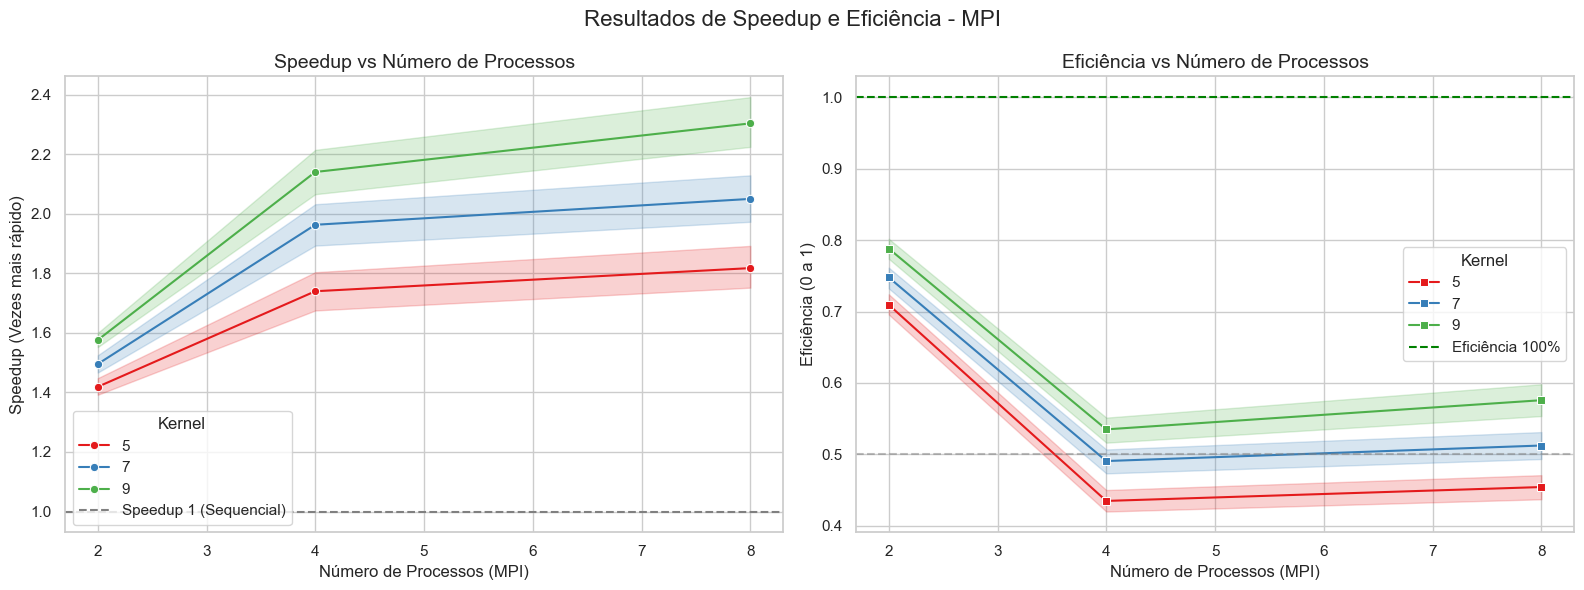

In [16]:
plot_threads_comparison(df_analise)

### 3.3 Comparação de desempenho entre execução MPI e OMP

Para a comparação entre as abordagens MPI e OpenMP, foi selecionada a melhor configuração de teste OMP para cada kernel, comparando-a com os resultados obtidos com MPI, considerando o mesmo kernel e o mesmo número de processos/threads.

In [17]:
omp_best_config = [
    {
        'windowd_size': 5,
        'batch_size': 2,
        'type': 'static',
        'threads': 8
    },
    {
        'windowd_size': 7,
        'batch_size': 0,
        'type': 'static',
        'threads': 8
    },
    {
        'windowd_size': 9,
        'batch_size': 0,
        'type': 'static',
        'threads': 8
    }, 
]

In [18]:
### leitura omp ###
data_frames = []
for obj in omp_best_config:
    thread = obj['threads']
    kernel = obj['windowd_size']
    type_schedule = obj['type']
    batch_size = obj['batch_size']
    filename = f"slices_{type_schedule}{batch_size}_t{thread}_k{kernel}.txt"
    filepath = os.path.join(OUTPUT_DIR, filename)
    if os.path.exists(filepath):
        log_content = read_log(filepath)
        df = parse_log(log_content)
        data_frames.append(df)
        df['threads'] = thread
        df['type'] = 'omp'
        data_frames.append(df)
    else:
        print(f"Arquivo {filename} não encontrado.")

In [19]:
df_omp = pd.concat(data_frames, ignore_index=True)
df_final = pd.concat([df_final, df_omp], ignore_index=True)
df_medio = df_final.groupby(colunas_agrupamento, dropna=False)[colunas_tempo].mean().reset_index()

In [20]:
# separacao de dados sequenciais
df_seq = df_medio[df_medio['type'] == 'sequencial'].copy()
df_seq = df_seq[['id', 'tempo_total', 'windows_size', 'cortes']].rename(columns={'tempo_total': 'tempo_total_seq'})

# separacao de dados paralelos
df_par = df_medio[df_medio['type'] != 'sequencial'].copy()

# juncao dos dados sequenciais e paralelos para analise de speedup e eficiencia
df_analise = df_par.merge(df_seq, on=['id', 'windows_size', 'cortes'], how='inner')

# calculo de speedup e eficiencia
df_analise['speedup_total'] = df_analise['tempo_total_seq'] / df_analise['tempo_total']
df_analise['eficiencia'] = df_analise['speedup_total'] / df_analise['threads']
df_analise.loc[df_analise['threads'] > NUCLEOS_FISICOS, 'eficiencia'] = df_analise[df_analise['threads'] > NUCLEOS_FISICOS]['speedup_total'] / NUCLEOS_FISICOS

In [21]:
resumo_by_kernel = df_analise.groupby(['threads', 'windows_size', 'type']).agg(
    tempo_total_medio=('tempo_total', 'mean'),
    tempo_total_medio_seq=('tempo_total_seq', 'mean'),
    speedup_medio=('speedup_total', 'mean'),
    eficiencia_media=('eficiencia', 'mean')
).reset_index()

resumo_by_kernel['speedup_medio'] = resumo_by_kernel['speedup_medio'].round(4)
resumo_by_kernel['tempo_total_medio'] = resumo_by_kernel['tempo_total_medio'].round(4)
resumo_by_kernel['tempo_total_medio_seq'] = resumo_by_kernel['tempo_total_medio_seq'].round(4)
resumo_by_kernel['eficiencia_media'] = resumo_by_kernel['eficiencia_media'].round(4)

Ao utilizar a paralelização por MPI, foi possível obter um ganho de desempenho superior ao da melhor configuração de OpenMP, com speedup médio de 1.81x para o kernel 5, 2.05x para o kernel 7 e 2.3x para o kernel 9, considerando a execução com 8 processos. 


Ao observar outros números de processos, o uso de 8 threads em OpenMP apresentou desempenho semelhante ao uso de 4 processos em MPI, o que indica que a abordagem de multithreading não foi tão eficiente quanto a de multiprocessamento — possivelmente devido ao custo de gerenciamento das threads e à contenção de recursos compartilhados, como a memória.

In [22]:
resumo_by_kernel[resumo_by_kernel['type'] == 'omp'].sort_values(by=['threads', 'windows_size'])

,threads,windows_size,type,tempo_total_medio,tempo_total_medio_seq,speedup_medio,eficiencia_media
7,8.0,5,omp,1.5435,2.8519,1.7412,0.4353
9,8.0,7,omp,2.0884,4.2865,1.9016,0.4754
11,8.0,9,omp,2.5143,5.9341,2.1675,0.5419


In [23]:
resumo_by_kernel[resumo_by_kernel['type'] == 'mpi'].sort_values(by=['windows_size', 'speedup_medio'], ascending=[True, False])

,threads,windows_size,type,tempo_total_medio,tempo_total_medio_seq,speedup_medio,eficiencia_media
6,8.0,5,mpi,1.4695,2.8519,1.8176,0.4544
3,4.0,5,mpi,1.5379,2.8519,1.7398,0.4350
0,2.0,5,mpi,1.9311,2.8519,1.4189,0.7094
8,8.0,7,mpi,1.9345,4.2865,2.0500,0.5125
4,4.0,7,mpi,2.0236,4.2865,1.9631,0.4908
1,2.0,7,mpi,2.7564,4.2865,1.4954,0.7477
10,8.0,9,mpi,2.3649,5.9341,2.3037,0.5759
5,4.0,9,mpi,2.5554,5.9341,2.1404,0.5351
2,2.0,9,mpi,3.5980,5.9341,1.5761,0.7881


## 4. Conclusão

Este trabalho teve como objetivo avaliar o desempenho da implementação em MPI para o problema de busca de similaridade entre cortes de tomografias computadorizadas, comparando-a com as versões sequencial e OpenMP desenvolvidas anteriormente.

Os testes de corretude confirmaram que a versão MPI produz resultados idênticos aos da versão sequencial, tanto em relação ao valor máximo de SSIM quanto ao índice do corte correspondente, validando a fidelidade da implementação paralela.

Em termos de desempenho, a versão MPI apresentou ganhos de speedup crescentes com o aumento do número de processos, chegando a 2.3x com 8 processos no kernel 9 — o maior volume de dados testado. Esse comportamento reforça a expectativa de que kernels maiores, por representarem um custo computacional mais elevado, tendem a se beneficiar mais da paralelização. Ainda assim, a eficiência observada ficou em torno de 0.5 para as configurações com maior número de processos, as melhores eficiências, por sua vez, foram alcançadas com 2 processos, evidenciando que o ganho relativo ao custo de paralelização é mais vantajoso nesse cenário.

A comparação entre MPI e OpenMP mostrou que a abordagem de multiprocessamento superou a de multithreading em todos os kernels avaliados, com speedups médios de 1.81x, 2.05x e 2.3x para os kernels 5, 7 e 9, respectivamente, na configuração com 8 processos/threads. Esse resultado sugere que, para o problema tratado, o isolamento de memória entre processos e a divisão explícita dos dados via MPI_Scatterv trouxeram vantagens em relação ao compartilhamento de memória do OpenMP, possivelmente por reduzir a contenção de recursos e o overhead de sincronização entre threads. De forma geral, os resultados indicam que a implementação em MPI foi capaz de acelerar o processamento sem comprometer a corretude do algoritmo, apresentando desempenho superior ao da versão com OpenMP no hardware utilizado. 